In [ ]:
!pip install statsmodels pmdarima --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams["figure.figsize"] = (12,5)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.5 MB/s eta 0:00:00


In [ ]:
admission_df = pd.read_csv("/content/HDHI Admission data.csv")
mortality_df = pd.read_csv("/content/HDHI Mortality Data.csv")
pollution_df = pd.read_csv("/content/HDHI Pollution Data.csv")

print(admission_df.columns)
print(mortality_df.columns)
print(pollution_df.columns)


Index(['SNO', 'MRD No.', 'D.O.A', 'D.O.D', 'AGE', 'GENDER', 'RURAL',
       'TYPE OF ADMISSION-EMERGENCY/OPD', 'month year', 'DURATION OF STAY',
       'duration of intensive unit stay', 'OUTCOME', 'SMOKING ', 'ALCOHOL',
       'DM', 'HTN', 'CAD', 'PRIOR CMP', 'CKD', 'HB', 'TLC', 'PLATELETS',
       'GLUCOSE', 'UREA', 'CREATININE', 'BNP', 'RAISED CARDIAC ENZYMES', 'EF',
       'SEVERE ANAEMIA', 'ANAEMIA', 'STABLE ANGINA', 'ACS', 'STEMI',
       'ATYPICAL CHEST PAIN', 'HEART FAILURE', 'HFREF', 'HFNEF', 'VALVULAR',
       'CHB', 'SSS', 'AKI', 'CVA INFRACT', 'CVA BLEED', 'AF', 'VT', 'PSVT',
       'CONGENITAL', 'UTI', 'NEURO CARDIOGENIC SYNCOPE', 'ORTHOSTATIC',
       'INFECTIVE ENDOCARDITIS', 'DVT', 'CARDIOGENIC SHOCK', 'SHOCK',
       'PULMONARY EMBOLISM', 'CHEST INFECTION'],
      dtype='object')
Index(['S.NO', 'MRD', 'AGE', 'GENDER ', 'RURAL/URBAN', 'DATE OF BROUGHT DEAD'], dtype='object')
Index(['DATE', 'AQI', 'PM2.5 AVG', 'PM2.5 MIN', 'PM2.5 MAX', 'PM10 AVG',
       'PM10 MIN', 'PM1

In [ ]:
# Rename date columns to a common name: Date
admission_df = admission_df.rename(columns={'D.O.A': 'Date'})
mortality_df = mortality_df.rename(columns={'DATE OF BROUGHT DEAD': 'Date'})
pollution_df = pollution_df.rename(columns={'DATE': 'Date'})

# Convert to datetime
admission_df['Date'] = pd.to_datetime(admission_df['Date'], errors='coerce')
mortality_df['Date'] = pd.to_datetime(mortality_df['Date'], errors='coerce')
pollution_df['Date'] = pd.to_datetime(pollution_df['Date'], errors='coerce')

# Drop rows with invalid dates
admission_df = admission_df.dropna(subset=['Date'])
mortality_df = mortality_df.dropna(subset=['Date'])
pollution_df = pollution_df.dropna(subset=['Date'])


In [ ]:
daily_admissions = admission_df.groupby('Date').size().reset_index(name='Admissions')
daily_mortality = mortality_df.groupby('Date').size().reset_index(name='Deaths')
daily_pollution = pollution_df.groupby('Date').mean(numeric_only=True).reset_index()


In [ ]:
merged_df = pd.merge(daily_admissions, daily_mortality, on='Date', how='inner')
merged_df = pd.merge(merged_df, daily_pollution, on='Date', how='inner')

merged_df = merged_df.sort_values('Date').set_index('Date')

ts = merged_df['Admissions']
ts.head()


,Admissions
Date,
2017-04-02,13
2017-04-04,20
2017-04-06,11
2017-04-08,11
2017-04-09,8


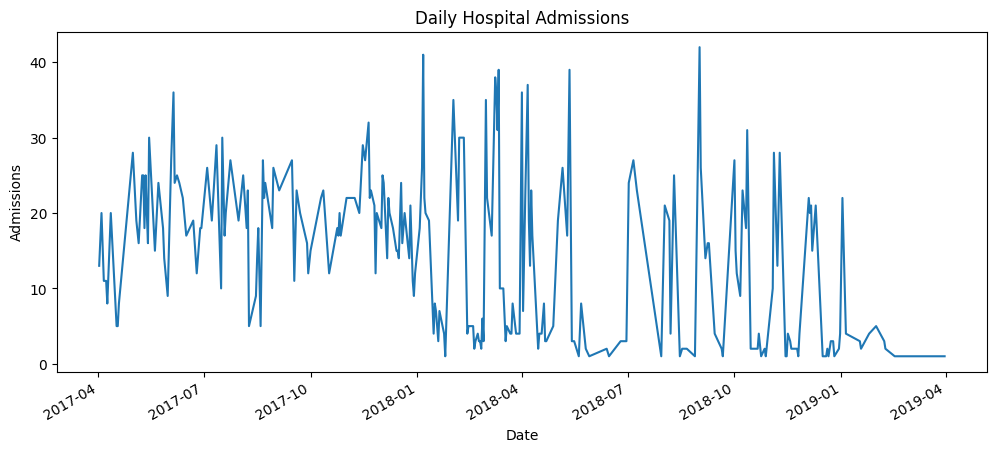

In [ ]:
ts.plot(title="Daily Hospital Admissions")
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.show()


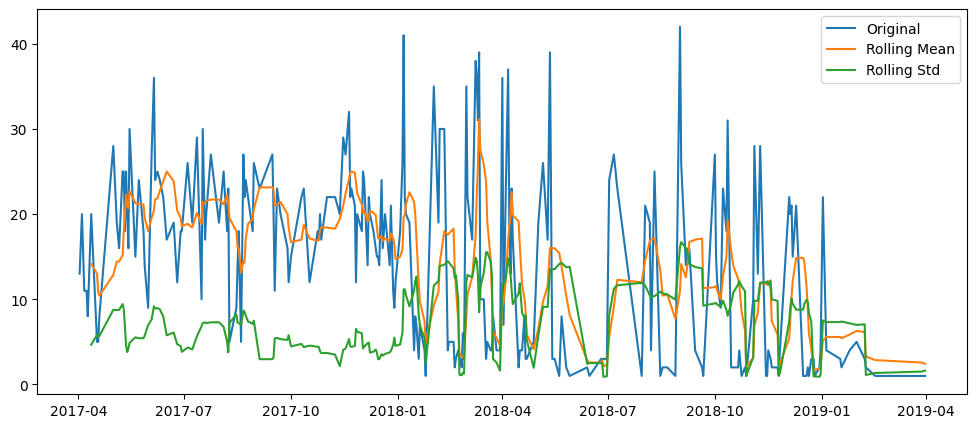

ADF Statistic: -1.2358700753351766
p-value: 0.6579781831119496


In [ ]:
rolmean = ts.rolling(7).mean()
rolstd = ts.rolling(7).std()

plt.plot(ts, label='Original')
plt.plot(rolmean, label='Rolling Mean')
plt.plot(rolstd, label='Rolling Std')
plt.legend()
plt.show()

adf = adfuller(ts.dropna())
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])


ADF Statistic (After Transform): -8.316678667147746
p-value (After Transform): 3.664845181736152e-13


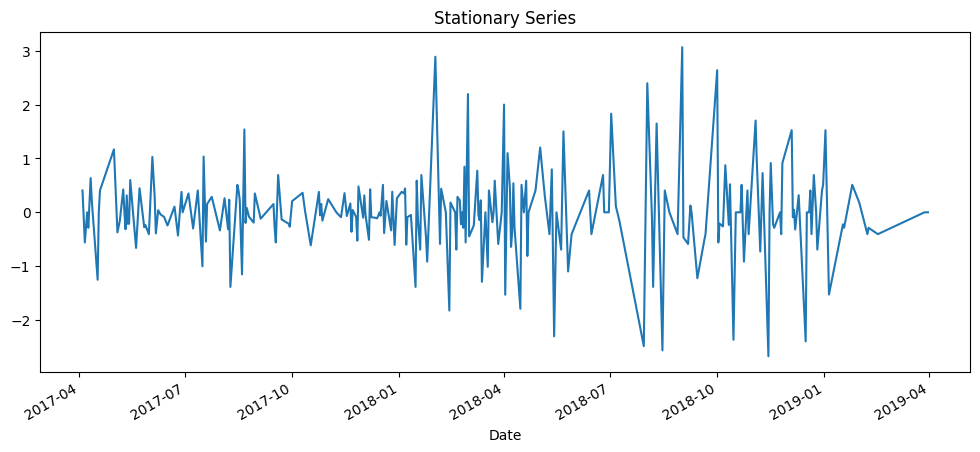

In [ ]:
ts_log = np.log1p(ts)
ts_log_diff = ts_log.diff().dropna()

adf2 = adfuller(ts_log_diff)
print("ADF Statistic (After Transform):", adf2[0])
print("p-value (After Transform):", adf2[1])

ts_log_diff.plot(title="Stationary Series")
plt.show()


In [ ]:
train = ts_log[:-30]
test = ts_log[-30:]


In [ ]:
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()
print(model_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Admissions   No. Observations:                  222
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -232.185
Date:                Fri, 06 Feb 2026   AIC                            474.371
Time:                        07:34:22   BIC                            491.361
Sample:                             0   HQIC                           481.231
                                - 222                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2864      0.553      0.518      0.605      -0.798       1.371
ar.L2          0.1594      0.259      0.615      0.538      -0.348       0.667
ma.L1         -0.8632      0.569     -1.518      0.1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


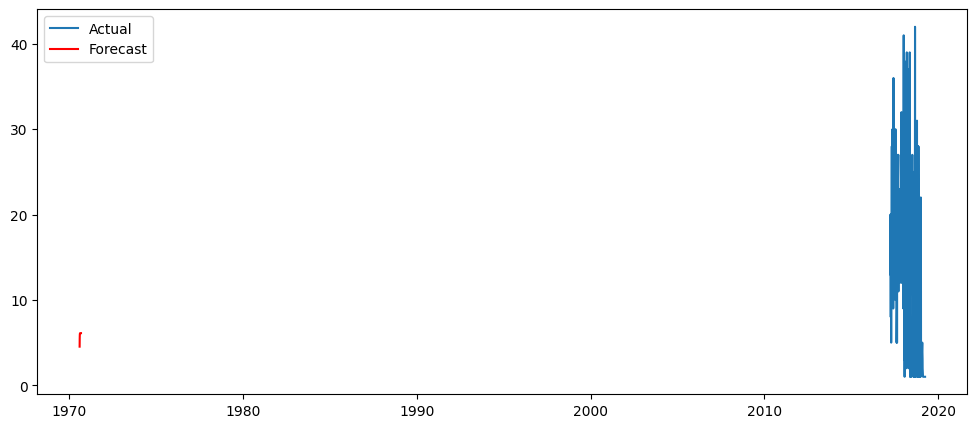

In [ ]:
forecast_log = model_fit.forecast(steps=30)
forecast = np.expm1(forecast_log)

plt.plot(ts, label="Actual")
plt.plot(forecast, color='red', label="Forecast")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, forecast)

print("RMSE:", rmse)
print("MAE:", mae)


RMSE: 7.307020147550907
MAE: 5.793299232278611
